In [30]:
import pandas as pd
import numpy as np

data = {
    'Name' : ['Praveen', 'Rahul', 'Ritik'],
    'Marks' : [86, 72, 90],
    'City' : ['Varanasi','Lucknow', 'Kanpur']

}
df = pd.DataFrame(data)
print(df) #PRINTS TABLE
print(df.describe()) #COUNT MEAN STD MAX
print(df.shape) #COUNT ROWS AND COLUMS
print(df.info())
print(df.dtypes)

print(df.head(2))

#Acess specific data
print(df['Marks'])
print(df[['Name','City']])
print(df.loc[1,'Name'])
#step 3
high_scorers = df[df['Marks'] > 80]
print(high_scorers)

Varanasi = df[df['City'] == 'Varanasi']
print(Varanasi)

#step 4
df['Grade'] = ['A', 'B', 'A+']
print(df)

df['Pass/Fail'] = df['Marks'].apply(lambda x: "Pass" if x>75 else 'Fail')
print(df)

#step 5
print("Average marks:", df['Marks'].mean())
print("Highest Marks:", df['Marks'].max())
print("lowest Marks:", df['Marks'].min())
print("Total Students:", df['Marks'].count())


      Name  Marks      City
0  Praveen     86  Varanasi
1    Rahul     72   Lucknow
2    Ritik     90    Kanpur
           Marks
count   3.000000
mean   82.666667
std     9.451631
min    72.000000
25%    79.000000
50%    86.000000
75%    88.000000
max    90.000000
(3, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    3 non-null      object
 1   Marks   3 non-null      int64 
 2   City    3 non-null      object
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes
None
Name     object
Marks     int64
City     object
dtype: object
      Name  Marks      City
0  Praveen     86  Varanasi
1    Rahul     72   Lucknow
0    86
1    72
2    90
Name: Marks, dtype: int64
      Name      City
0  Praveen  Varanasi
1    Rahul   Lucknow
2    Ritik    Kanpur
Rahul
      Name  Marks      City
0  Praveen     86  Varanasi
2    Ritik     90    Kanpur
      Name  Marks 

In [48]:
df = pd.read_csv('train.csv', encoding = 'latin-1')
print(df.shape)
print(df.head())
print(df.columns)


(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [44]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding = 'latin-1')

print(df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
print(df.describe())

(9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 3 rows:
   Row ID        Order ID Order Date   Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
1       2  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
2       3  CA-2016-138688  6/12/2016   6/16/2016  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...       42420   
1      Claire Gute   Consumer  United States    Henderson  ...       42420   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...       90036   

   Region       Product ID         Category Sub-Category  \
0   South  FUR-BO-

In [45]:
# Convert date column first
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year

# QUESTION 1: Which Region generates most Sales?
print("=== Q1: Sales by Region ===")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False))

# QUESTION 2: Which Category is most profitable?
print("\n=== Q2: Profit by Category ===")
print(df.groupby('Category')['Profit'].sum().sort_values(ascending=False))

# QUESTION 3: Which Year had highest sales?
print("\n=== Q3: Sales by Year ===")
print(df.groupby('Year')['Sales'].sum().sort_values(ascending=False))

# QUESTION 4: Top 5 most profitable products?
print("\n=== Q4: Top 5 Products by Profit ===")
print(df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(5))

# QUESTION 5: Does discount hurt profit? (correlation)
print("\n=== Q5: Correlation between Discount and Profit ===")
print(df[['Discount', 'Profit']].corr())

=== Q1: Sales by Region ===
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

=== Q2: Profit by Category ===
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

=== Q3: Sales by Year ===
Year
2017    733215.2552
2016    609205.5980
2014    484247.4981
2015    470532.5090
Name: Sales, dtype: float64

=== Q4: Top 5 Products by Profit ===
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64

=== Q5: Cor

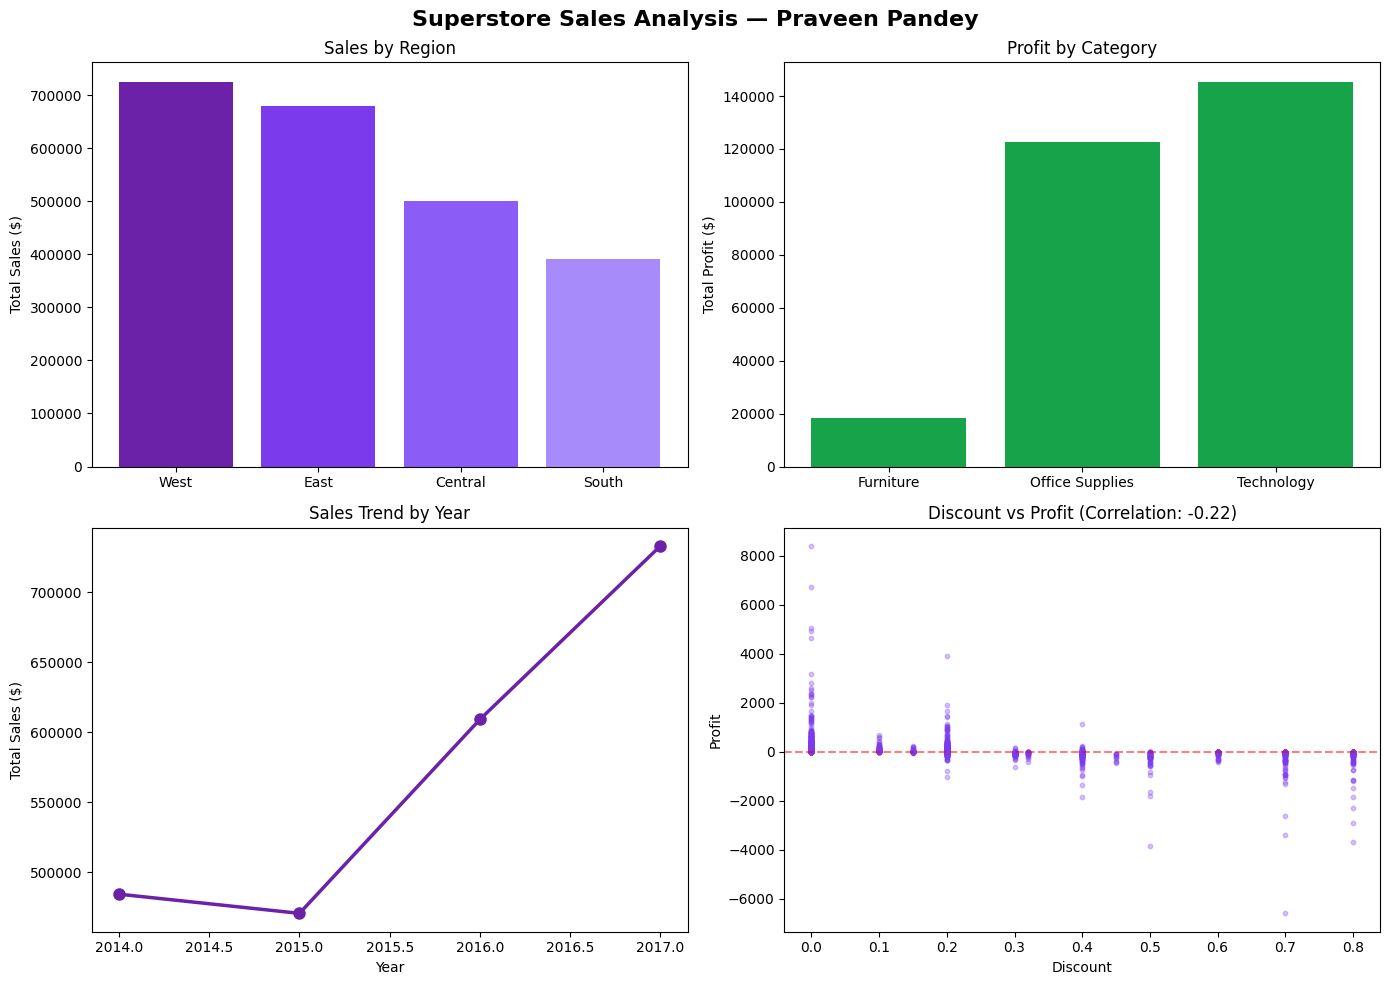

Chart saved!


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Analysis — Praveen Pandey',
             fontsize=16, fontweight='bold')

# Chart 1: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(region_sales.index, region_sales.values, color=['#6B21A8','#7C3AED','#8B5CF6','#A78BFA'])
axes[0,0].set_title('Sales by Region')
axes[0,0].set_ylabel('Total Sales ($)')

# Chart 2: Profit by Category
cat_profit = df.groupby('Category')['Profit'].sum()
colors = ['#16A34A' if x > 0 else '#DC2626' for x in cat_profit.values]
axes[0,1].bar(cat_profit.index, cat_profit.values, color=colors)
axes[0,1].set_title('Profit by Category')
axes[0,1].set_ylabel('Total Profit ($)')

# Chart 3: Sales by Year
year_sales = df.groupby('Year')['Sales'].sum()
axes[1,0].plot(year_sales.index, year_sales.values,
               marker='o', color='#6B21A8', linewidth=2.5, markersize=8)
axes[1,0].set_title('Sales Trend by Year')
axes[1,0].set_ylabel('Total Sales ($)')
axes[1,0].set_xlabel('Year')

# Chart 4: Discount vs Profit scatter
axes[1,1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='#7C3AED', s=10)
axes[1,1].set_title('Discount vs Profit (Correlation: -0.22)')
axes[1,1].set_xlabel('Discount')
axes[1,1].set_ylabel('Profit')
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('superstore_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")